# Metrics and Evaluacion - California Housing Dataset

In [1]:
from sklearn.datasets import fetch_california_housing

x, y = fetch_california_housing(return_X_y=True, as_frame=True)

x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [2]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


<Axes: xlabel='MedHouseVal', ylabel='Count'>

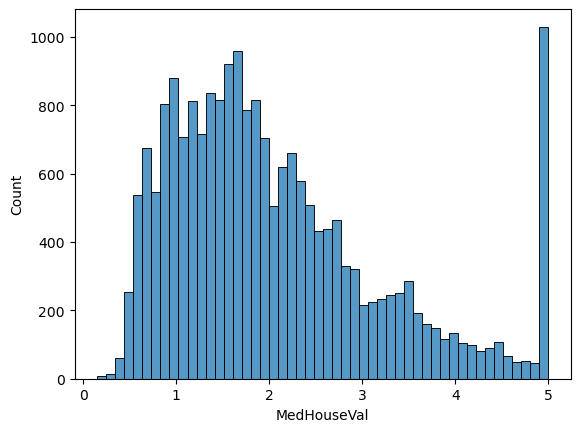

In [3]:
import seaborn as sns

sns.histplot(y, bins=50)

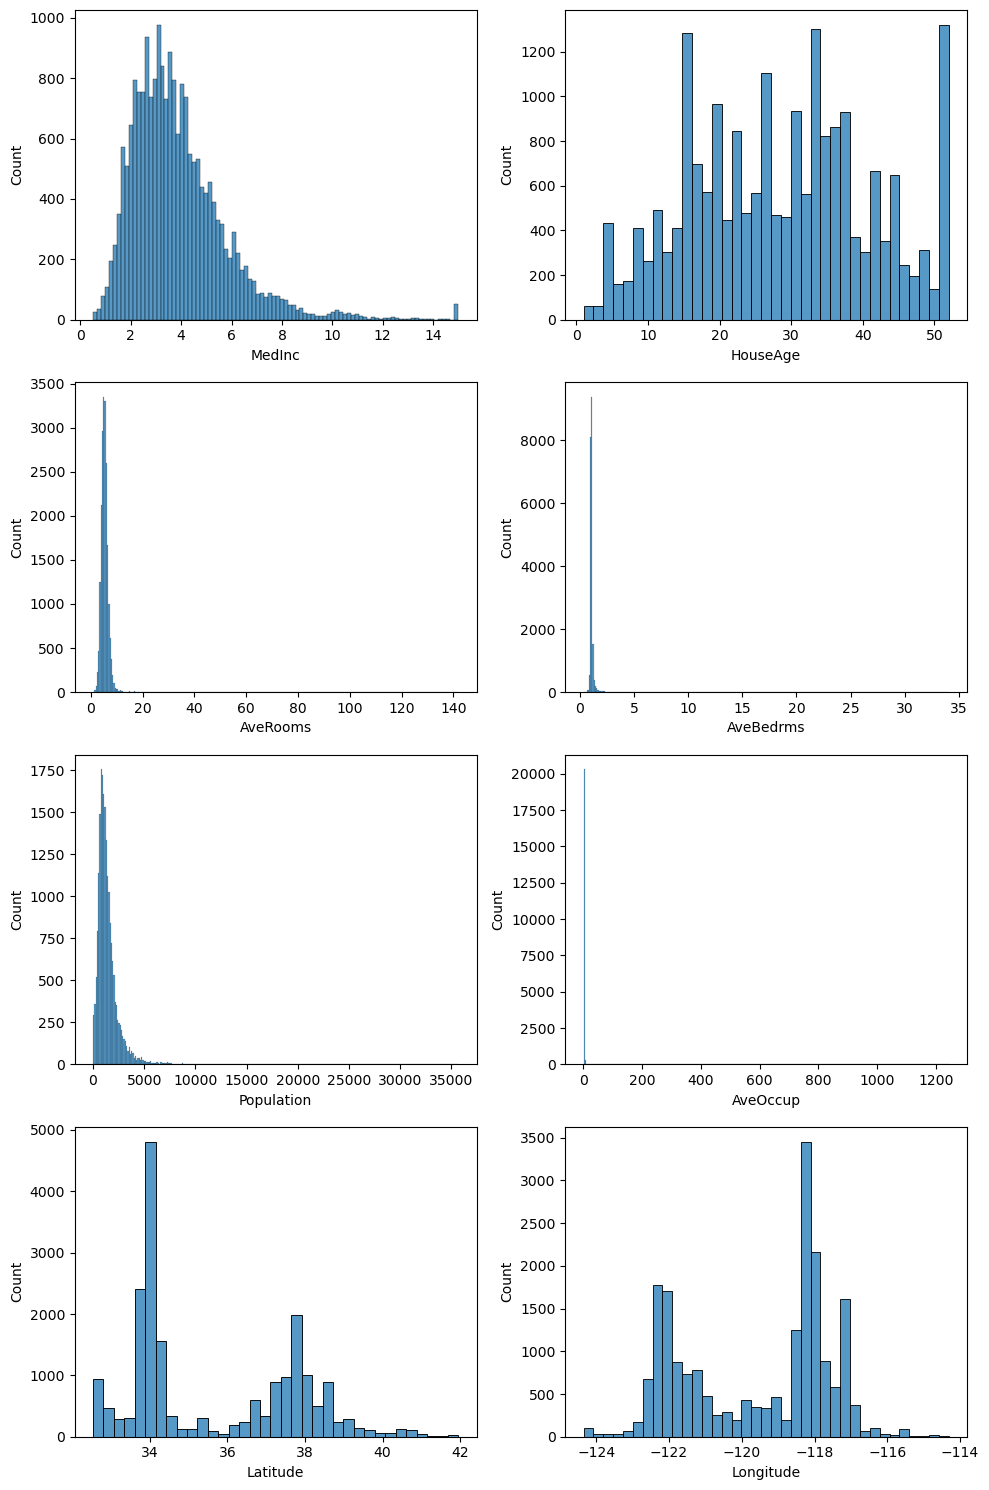

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 2, figsize=(10,15))

for ax, col in zip(axs.ravel(), x.columns):
    sns.histplot(x[col], ax=ax)

plt.tight_layout()

<Axes: xlabel='Longitude', ylabel='Latitude'>

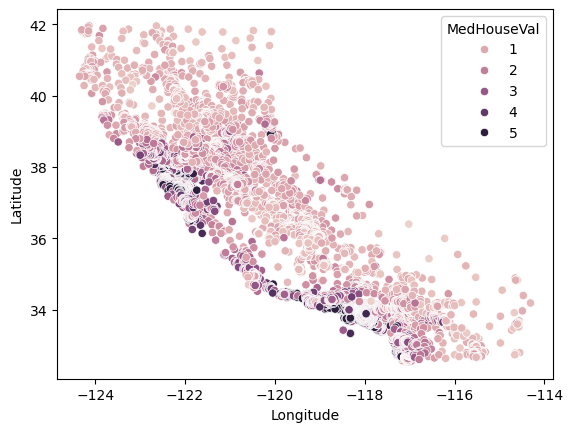

In [5]:
sns.scatterplot(x=x["Longitude"], y=x["Latitude"], hue=y)

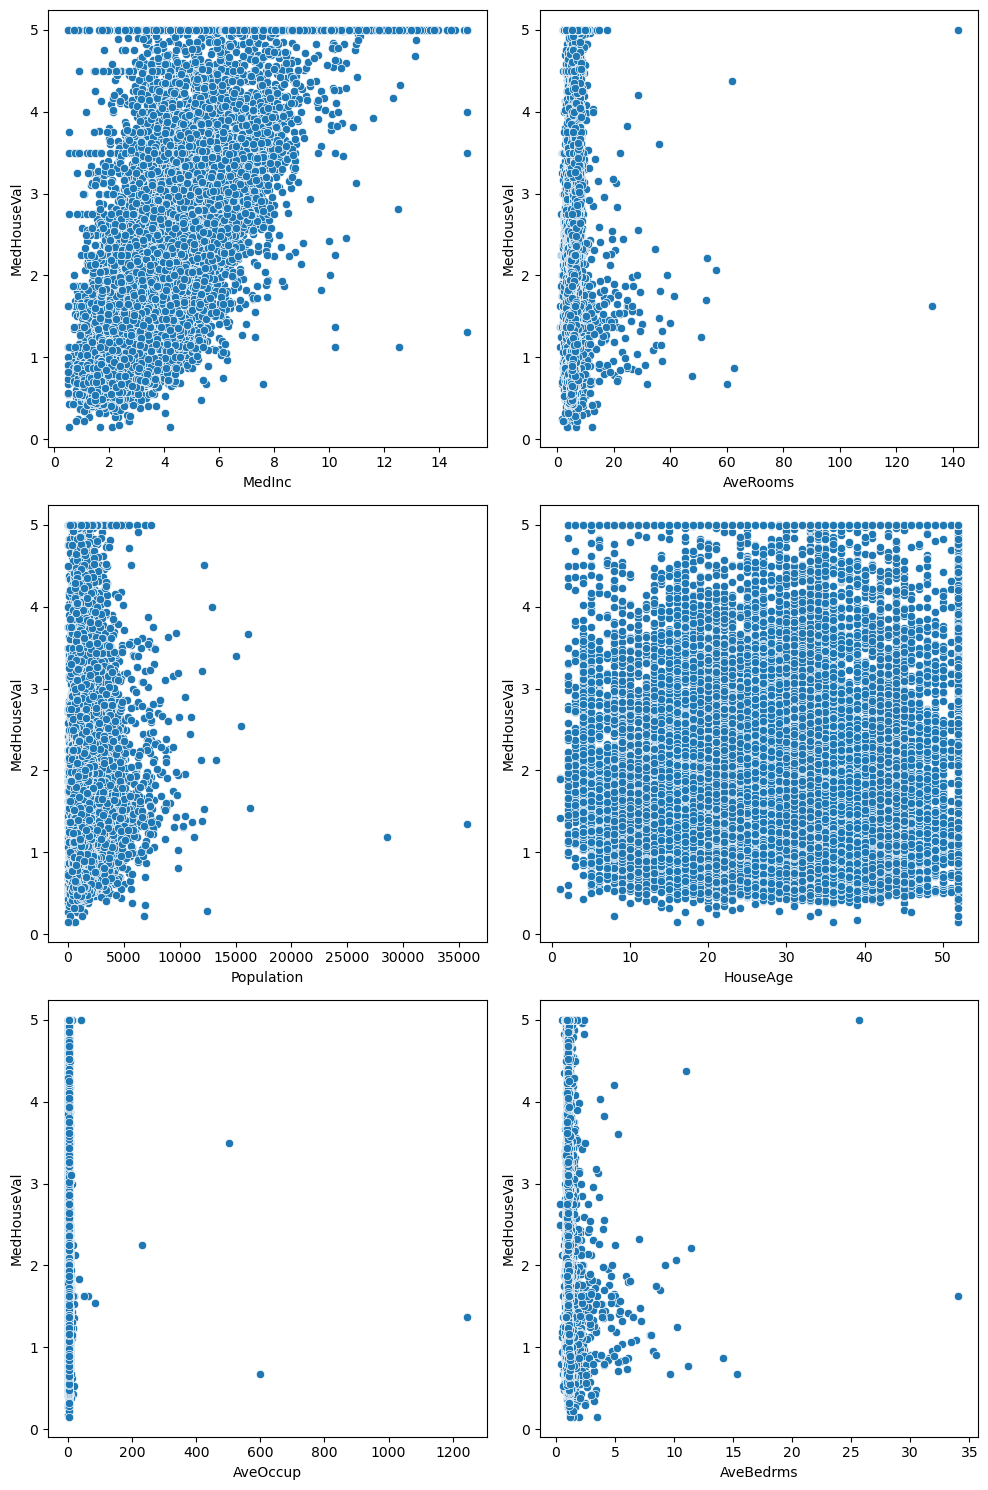

In [6]:
cols = set(x.columns) - {"Longitude","Latitude"}

fig, axs = plt.subplots(3, 2, figsize=(10,15))

for ax, col in zip(axs.ravel(), cols):
    sns.scatterplot(x=x[col],y=y, ax=ax)

plt.tight_layout()

<Axes: ylabel='MedInc'>

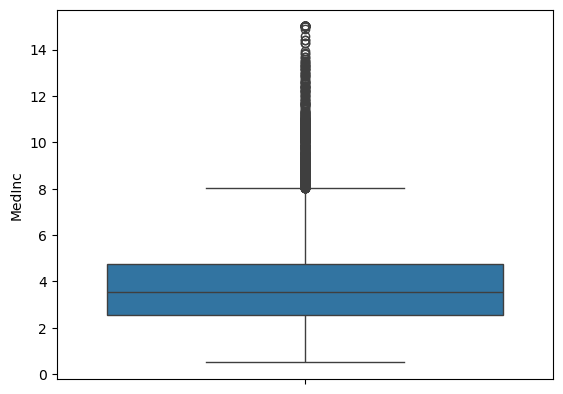

In [7]:
sns.boxplot(x["MedInc"])

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_trainval, y_train, y_trainval = train_test_split(x, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_trainval, y_trainval, test_size=0.5, random_state=42)

In [9]:
Q1 = x_train.quantile(0.25)
Q3 = x_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

x_train_capped = x_train.copy()
x_test_capped = x_test.copy()
x_val_capped = x_val.copy()

for col in x_train.columns:
    x_train_capped[col] = x_train[col].clip(lower=lower_bound[col], upper=upper_bound[col])
    x_test_capped[col] = x_test[col].clip(lower=lower_bound[col], upper=upper_bound[col])
    x_val_capped[col] = x_val[col].clip(lower=lower_bound[col], upper=upper_bound[col])

x_train = x_train_capped
x_test= x_test_capped
x_val = x_val_capped


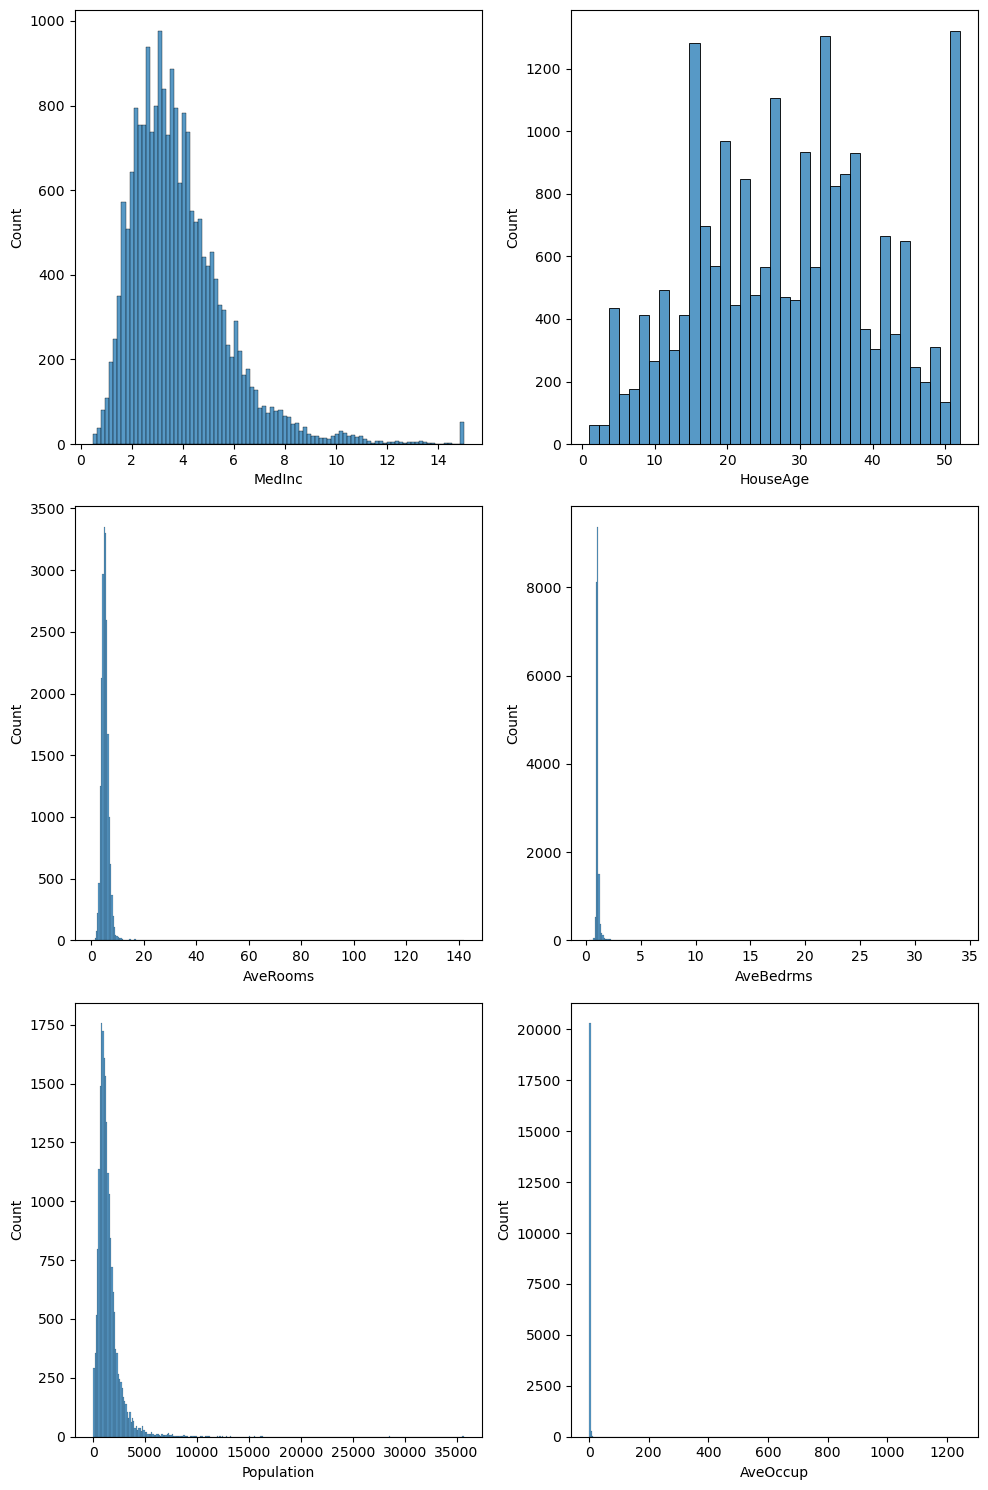

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(10,15))

for ax, col in zip(axs.ravel(), x_train.columns):
    sns.histplot(x[col], ax=ax)

plt.tight_layout()

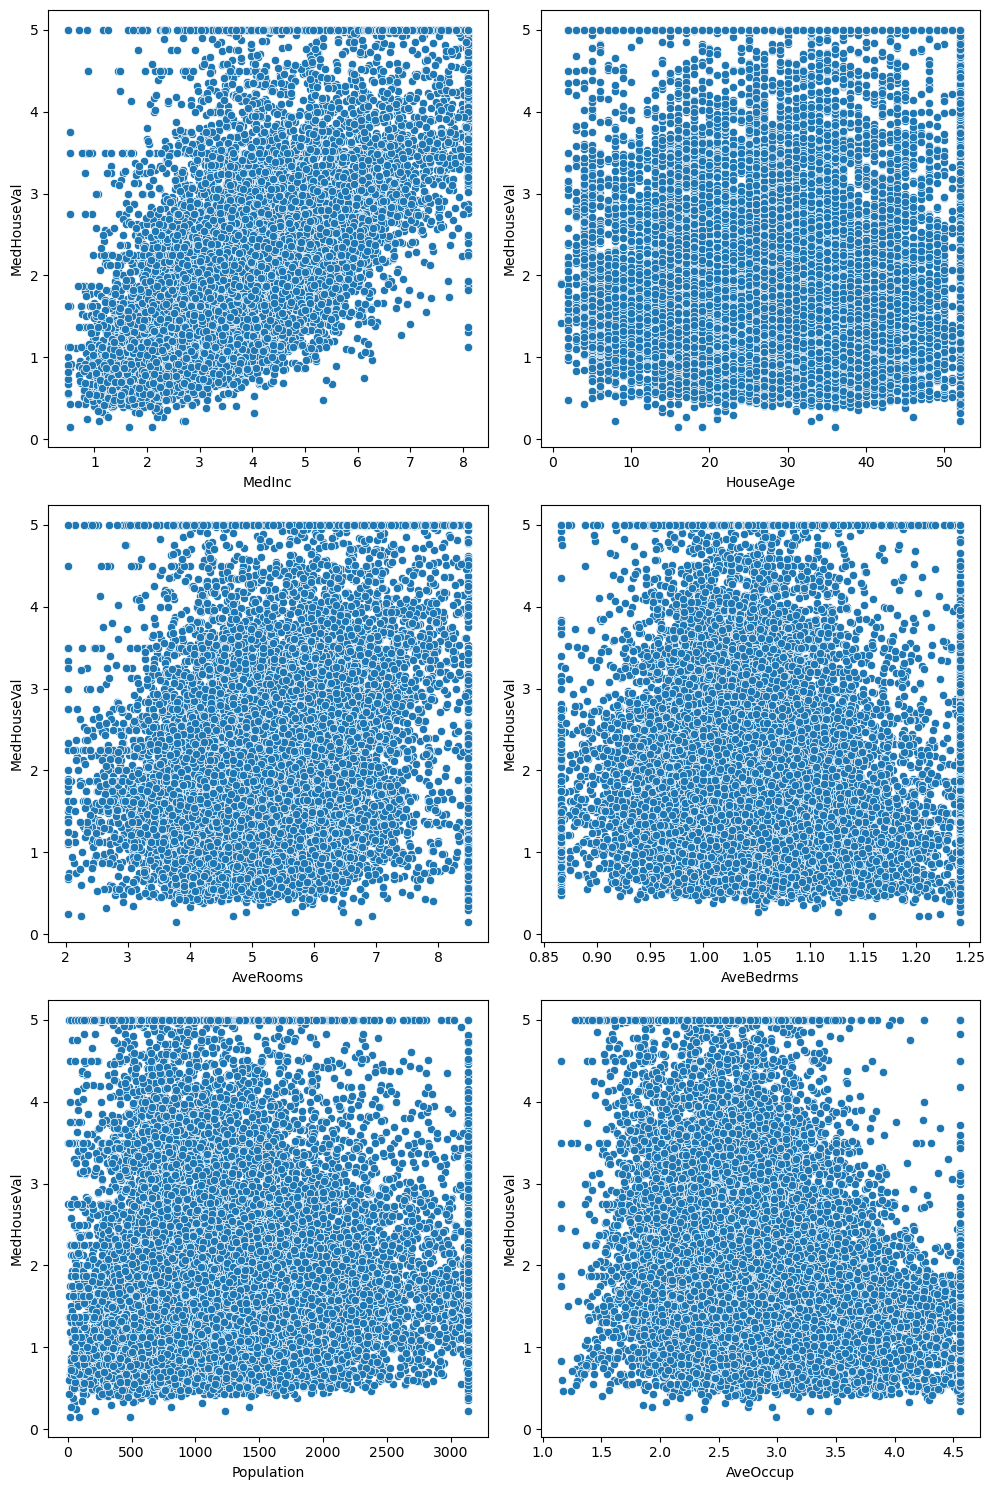

In [11]:
fig, axs = plt.subplots(3, 2, figsize=(10,15))

for ax, col in zip(axs.ravel(), x_train.columns):
    sns.scatterplot(x=x_train[col], y=y, ax=ax)

plt.tight_layout()

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

preprocessing = make_pipeline(
    ColumnTransformer(transformers=
                      [
                          ("num", MinMaxScaler(), x.columns)
                      ])
)

In [13]:
x_train_processed = preprocessing.fit_transform(x_train)
x_test_processed = preprocessing.fit_transform(x_test)
x_val_processed = preprocessing.fit_transform(x_val)

In [14]:
x_train_processed 

array([[0.36393308, 0.62745098, 0.46288192, ..., 0.7459508 , 0.01702128,
        0.72908367],
       [0.4368463 , 0.94117647, 0.3783391 , ..., 0.17213852, 0.12978723,
        0.61653386],
       [0.48218463, 0.05882353, 0.56048662, ..., 0.46147057, 0.22446809,
        0.38545817],
       ...,
       [0.32104761, 0.68627451, 0.3026969 , ..., 0.6402926 , 0.15744681,
        0.59462151],
       [0.68829073, 0.2745098 , 0.67694465, ..., 0.59530398, 0.53510638,
        0.23804781],
       [0.27371798, 1.        , 0.21193442, ..., 0.28098483, 0.55531915,
        0.19223108]], shape=(16512, 8))

## Model Training and Evaluation

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train_processed, y_train)
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = root_mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    return {"MAE": mae, "MSE":mse, "R2": r2, "RMSE": rmse}

In [17]:
import pandas as pd

train_metrics = evaluate_model(model, x_train_processed, y_train)
test_metrics = evaluate_model(model, x_test_processed, y_test)

metrics_df = pd.DataFrame({"Train": train_metrics, "Test": test_metrics})
metrics_df.T

,MAE,MSE,R2,RMSE
Train,0.492680,0.437935,0.672395,0.661767
Test,0.502049,0.479701,0.635698,0.692604


In [18]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(hidden_layer_sizes=(50, 50), solver='adam')

model.fit(x_train_processed, y_train)

train_metrics = evaluate_model(model, x_train_processed, y_train)
test_metrics = evaluate_model(model, x_test_processed, y_test)

metrics_df = pd.DataFrame({"Train": train_metrics, "Test": test_metrics})
metrics_df.T

c:\Users\hacki\.conda\envs\jupyter-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,MAE,MSE,R2,RMSE
Train,0.377093,0.278398,0.791740,0.527634
Test,0.370427,0.293208,0.777327,0.541486


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes" : [(50,), (100,), (50, 50)],
    "solver": ["adam", "lbfgs"],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search = GridSearchCV(
    MLPRegressor(),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",)

In [20]:
grid_search.fit(x_train_processed, y_train)

c:\Users\hacki\.conda\envs\jupyter-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\hacki\.conda\envs\jupyter-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\hacki\.conda\envs\jupyter-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\hacki\.conda\envs\jupyter-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of ite

,estimator,MLPRegressor()
,param_grid,"{'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(50,), (100,), ...], 'solver': ['adam', 'lbfgs']}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [21]:
grid_search.best_params_

{'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}

In [22]:
model = grid_search.best_estimator_

train_metrics = evaluate_model(model, x_train_processed, y_train)
test_metrics = evaluate_model(model, x_test_processed, y_test)

metrics_df = pd.DataFrame({"Train": train_metrics, "Test": test_metrics})
metrics_df.T

,MAE,MSE,R2,RMSE
Train,0.358494,0.262798,0.803409,0.512638
Test,0.365097,0.295491,0.775593,0.543591


In [23]:
val_metrics = evaluate_model(model, x_val_processed, y_val)
val_metrics

{'MAE': 0.37435599600799196,
 'MSE': 0.28451134003692846,
 'R2': 0.781710637025935,
 'RMSE': 0.5333960442644176}